In [1]:
import pandas as pd
import numpy as np
import os
import glob
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

os. getcwd()

'C:\\Users\\rivera30\\OneDrive - NYU Langone Health\\Dissertation\\aim1\\cannabispol_var\\code'

Cannabis policy data was donwloaded from here:
https://alcoholpolicy.niaaa.nih.gov/policy-topics/download-policy-topic-data

We obtained variables if by the end of the year the state had the policy

In [2]:
path="C:\\Users\\rivera30\\OneDrive - NYU Langone Health\\CannabisLaws_LTA\\cannabis_lta\\data\\1_raw\\APIS\\"

In [3]:
#Loop to rename files and make data cleaning and extraction easier

#volume 1
for year in range(2012, 2023):
    for file in os.listdir(path+str(year)):
        if file.startswith("export--recreational-use-of-cannabis-volume-1"):
            old_filepath = os.path.join(path+str(year), file)
            new_name = str(year)+"_recreational-use-of-cannabis-volume-1.zip"
            new_filepath = os.path.join(path+str(year), new_name)
            os.rename(old_filepath, new_filepath)
#volume 2            
for year in range(2012, 2023):
    for file in os.listdir(path+str(year)):
        if file.startswith("export--recreational-use-of-cannabis-volume-2"):
            old_filepath = os.path.join(path+str(year), file)
            new_name = str(year)+"_recreational-use-of-cannabis-volume-2.zip"
            new_filepath = os.path.join(path+str(year), new_name)
            os.rename(old_filepath, new_filepath)


In [4]:
year = 2021

zf = zipfile.ZipFile(path+str(year)+"\\"+str(year)+"_recreational-use-of-cannabis-volume-2.zip") 
df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-2.csv"))

#export-data-csv--recreational-use-of-cannabis-volume-1.csv

print(df.columns)

df.columns = ['statename', 'stateabbr', 'statefips','policiesasof', 'rml', 'vertprohibited', 'industrymakeup', 
              'trackingreq', 'pesticides', 'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
             'publicuse', 'homedelivery', 'opencontainer', 'notes', 'citationscount', 'citations', 'jurisnote',
             'rownote']

df.head()

Index(['Jurisdiction', 'Postal Code', 'FIPS Code', 'Policies as of',
       'Recreational Use Legalized', 'Vertical Integration Prohibited',
       'Industry Makeup', 'Tracking System Requirements', 'Use of Pesticides',
       'Health and Safety Warning Requirements', 'Packaging Requirements',
       'Advertising Restrictions: Youth', 'Advertising Restrictions: General',
       'Public Consumption', 'Home Delivery', 'Open Container', 'Notes',
       'Citations Count', 'Citations', 'Juris Note', 'Row Note'],
      dtype='object')


,statename,stateabbr,statefips,policiesasof,rml,vertprohibited,industrymakeup,trackingreq,pesticides,warningreq,...,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer,notes,citationscount,citations,jurisnote,rownote
0,Alabama,AL,1.0,12/31/2021,0,0,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,12/31/2021,1,0,Private Entities,1,No Law,Amount of THC; Breastfeeding; Child Access; Im...,...,Both,Both,Restricted,Prohibited,No Law,Row Note: \n\n Recreational Use Leg...,20 Citations,EB: 2014 Alaska Ballot Measure No. 2\n\nCS: Al...,NaN,Recreational Use Legalized:\n\nThe creation of...
2,Arizona,AZ,4.0,12/31/2021,1,0,Private Entities,1,Restricted; Testing Required,Amount of THC; Child Access; Impairment of Dri...,...,Both,Content,Prohibited,Prohibited,No Law,Row Note: \n\n Recreational Use Leg...,14 Citations,EB: 2021 Ariz. Sess. Laws ch. 394\n\nCS: Ariz....,NaN,Recreational Use Legalized:\n\nThe creation of...
3,Arkansas,AR,5.0,12/31/2021,0,0,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,12/31/2021,1,0,Private Entities,1,Restricted; Testing Required,Amount of THC; Breastfeeding; Child Access; Im...,...,Both,Both,Prohibited,Allowed,Prohibited,Row Note: \n\n Recreational Use Leg...,19 Citations,EB: 2016 Cal. Legis. Serv. Prop. 64\n\nCS: Cal...,NaN,Recreational Use Legalized:\n\nThe creation of...


In [5]:
null_data = df[df.isnull().any(axis=1)]

In [6]:
null_data

,statename,stateabbr,statefips,policiesasof,rml,vertprohibited,industrymakeup,trackingreq,pesticides,warningreq,...,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer,notes,citationscount,citations,jurisnote,rownote
0,Alabama,AL,1.0,12/31/2021,0,0,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,12/31/2021,1,0,Private Entities,1,No Law,Amount of THC; Breastfeeding; Child Access; Im...,...,Both,Both,Restricted,Prohibited,No Law,Row Note: \n\n Recreational Use Leg...,20 Citations,EB: 2014 Alaska Ballot Measure No. 2\n\nCS: Al...,NaN,Recreational Use Legalized:\n\nThe creation of...
2,Arizona,AZ,4.0,12/31/2021,1,0,Private Entities,1,Restricted; Testing Required,Amount of THC; Child Access; Impairment of Dri...,...,Both,Content,Prohibited,Prohibited,No Law,Row Note: \n\n Recreational Use Leg...,14 Citations,EB: 2021 Ariz. Sess. Laws ch. 394\n\nCS: Ariz....,NaN,Recreational Use Legalized:\n\nThe creation of...
3,Arkansas,AR,5.0,12/31/2021,0,0,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,12/31/2021,1,0,Private Entities,1,Restricted; Testing Required,Amount of THC; Breastfeeding; Child Access; Im...,...,Both,Both,Prohibited,Allowed,Prohibited,Row Note: \n\n Recreational Use Leg...,19 Citations,EB: 2016 Cal. Legis. Serv. Prop. 64\n\nCS: Cal...,NaN,Recreational Use Legalized:\n\nThe creation of...
5,Colorado,CO,8.0,12/31/2021,1,0,Private Entities,1,Restricted; Testing Required,Amount of THC; Breastfeeding; Child Access; Im...,...,Both,Both,Restricted,Allowed with Restrictions,No Law,Row Note: \n\n Recreational Use Leg...,33 Citations,"EB: 2019 Colo. Sess. Laws 315, § 5\n\nCS: Colo...",NaN,Recreational Use Legalized:\n\nThe creation of...
6,Connecticut,CT,9.0,12/31/2021,1,0,Private Entities,1,Restricted; Testing Required,Amount of THC; Breastfeeding; Child Access; Pr...,...,Both,Both,Prohibited,Allowed with Restrictions,Prohibited,Row Note: \n\n Recreational Use Leg...,11 Citations,EB: 2021 Conn. Pub. Acts 21–1\n\nCS: C.G.S.A. ...,NaN,"Recreational Use Legalized:\n\nOn June 17, 202..."
7,Delaware,DE,10.0,12/31/2021,0,0,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,District of Columbia,DC,11.0,12/31/2021,1,0,NaN,0,NaN,NaN,...,NaN,NaN,Prohibited,No Law,No Law,NaN,11 Citations,"EB: 2014 D.C. Stat 20-153, §2\n\nCS: D.C. Code...",NaN,NaN
9,Florida,FL,12.0,12/31/2021,0,0,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
year = 2012

zf = zipfile.ZipFile(path+str(year)+"\\"+str(year)+"_recreational-use-of-cannabis-volume-1.zip") 
df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-1.csv"))

#export-data-csv--recreational-use-of-cannabis-volume-1.csv

print(df.columns)

df.columns = ['statename', 'stateabbr', 'statefips', 'policiesasof',
       'rml', 'regagency', 'productspermitted',
       'cultivationres', 'retailsales_onpremises',
       'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh',
       'localauthority', 'notes1', 'citationscount1', 'citations1',
       'jurisnote1', 'rownote1']
  
df.head()

Index(['Jurisdiction', 'Postal Code', 'FIPS Code', 'Policies as of',
       'Recreational Use Legalized', 'Regulatory Agency', 'Products Permitted',
       'Cultivation Restrictions', 'Retail Sales - On-Premises',
       'Retail Sales - Off-Premises', 'Pricing Controls Imposed',
       'Tax Imposed', 'Underage Prohibitions', 'Impaired Driving Prohibitions',
       'Local Authority', 'Notes', 'Citations Count', 'Citations',
       'Juris Note', 'Row Note'],
      dtype='object')


,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,pricingcontrols,taxes,underageproh,impaireddrivingproh,localauthority,notes1,citationscount1,citations1,jurisnote1,rownote1
0,Alabama,AL,1.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
fp="C:\\Users\\rivera30\\OneDrive - NYU Langone Health\\CannabisLaws_LTA\\cannabis_lta\\data\\1_raw\\APIS\\"

In [9]:
# Loop

#vol1 policies
for year in range(2012, 2023):
    zf = zipfile.ZipFile(path+str(year)+"\\"+str(year)+"_recreational-use-of-cannabis-volume-1.zip") 
    df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-1.csv"))
    df.columns = ['statename', 'stateabbr', 'statefips', 'policiesasof',
       'rml', 'regagency', 'productspermitted',
       'cultivationres', 'retailsales_onpremises',
       'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh',
       'localauthority', 'notes1', 'citationscount1', 'citations1',
       'jurisnote1', 'rownote1']
    df["year"] = year
    df.to_csv(fp+"vol1_"+str(year)+".csv", index=False)
    

#vol2 policies
for year in range(2012, 2023):
    zf = zipfile.ZipFile(path+str(year)+"\\"+str(year)+"_recreational-use-of-cannabis-volume-2.zip") 
    df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-2.csv"))
    df.columns = ['statename', 'stateabbr', 'statefips','policiesasof', 'rml', 'vertprohibited', 
                  'industrymakeup', 'trackingreq', 'pesticides', 'warningreq', 'packagingreq', 
                  'advertising_youth', 'advertising_gen', 'publicuse', 'homedelivery', 
                  'opencontainer', 'notes2', 'citationscount2', 'citations2', 'jurisnote2',
                  'rownote2']
    df["year"] = year
    df.to_csv(fp+"vol2_"+str(year)+".csv", index=False)

In [10]:
# Example from here: https://java2blog.com/merge-multiple-csv-files-python/
#import pandas as pd
#files = ['file1.csv', 'file2.csv']
#df = pd.DataFrame()
#for file in files:
#    data = pd.read_csv(file)
#    df = pd.concat([df, data], axis=0)
#df.to_csv('merged_files.csv', index=False)


#merge all years of vol1 cannabis policies
files = ['vol1_2012.csv', 'vol1_2013.csv', 'vol1_2014.csv', 'vol1_2015.csv', 'vol1_2016.csv', 
         'vol1_2017.csv', 'vol1_2018.csv' , 'vol1_2019.csv', 'vol1_2020.csv', 'vol1_2021.csv']
df = pd.DataFrame()

for file in files:
    data = pd.read_csv(fp+file)
    df = pd.concat([df,data], axis=0)
df.to_csv(fp+'merged_vol1_2012_2021.csv', index=False)

#merge all years of vol2 cannabis policies
files = ['vol2_2012.csv', 'vol2_2013.csv', 'vol2_2014.csv', 'vol2_2015.csv', 'vol2_2016.csv', 
         'vol2_2017.csv', 'vol2_2018.csv' , 'vol2_2019.csv', 'vol2_2020.csv', 'vol2_2021.csv']

df = pd.DataFrame()

for file in files:

    data = pd.read_csv(fp+file)
    df = pd.concat([df, data], axis=0)
df.to_csv(fp+'merged_vol2_2012_2021.csv', index=False)

In [11]:
df1 = pd.read_csv(fp+'merged_vol1_2012_2021.csv')
df2 = pd.read_csv(fp+'merged_vol2_2012_2021.csv')

cannabispol = pd.merge(df1, df2, how='inner', on=['statename', 'stateabbr', 'statefips', 'policiesasof',
                                            'rml', 'year'])

cannabispol.to_csv(fp+"cannabispol_2012_2021.csv", index=False)

In [12]:
cannabispol.head()

,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,...,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer,notes2,citationscount2,citations2,jurisnote2,rownote2
0,Alabama,AL,1.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print(cannabispol.columns)

Index(['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml',
       'regagency', 'productspermitted', 'cultivationres',
       'retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh', 'localauthority',
       'notes1', 'citationscount1', 'citations1', 'jurisnote1', 'rownote1',
       'year', 'vertprohibited', 'industrymakeup', 'trackingreq', 'pesticides',
       'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
       'publicuse', 'homedelivery', 'opencontainer', 'notes2',
       'citationscount2', 'citations2', 'jurisnote2', 'rownote2'],
      dtype='object')


In [14]:
pd.crosstab(cannabispol['year'], cannabispol['regagency'])

regagency,Bureau of Cannabis Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health,Bureau of Marijuana Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health,Cannabis Compliance Board,"Cannabis Control Board\nThe Agency of Agriculture, Food and Markets",Cannabis Control Board; Officeof Cannabis Management,Cannabis Control Commission,Cannabis Control Division,Cannabis Regulatory Commission,Department of Administrative and Financial Services,Department of Agriculture; Department of Commerce and Economic Opportunity; Department of State Police; Department of Financial and Professional Regulation; Department of Revenue; Office of the Treasurer,...,Department of Revenue,Department of Taxation,Marijuana Control Board,"Marijuana Enforcement Division, Department of Revenue","Marijuana Regulatory Agency, Department of Licensing and Regulatory Affairs",Oregon Liquor Control Commission,Oregon Liquor and Cannabis Commission,Virginia Cannabis Control Authority,Washington State Liquor Board,Washington State Liquor and Cannabis Board
year,,,,,,,,,,,,,,,,,,,,,
2012,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,1
2016,0,1,0,0,0,1,0,0,0,0,...,0,0,1,1,0,1,0,0,0,1
2017,1,0,0,0,0,1,0,0,1,0,...,0,1,1,1,0,1,0,0,0,1
2018,1,0,0,0,0,1,0,0,1,0,...,0,1,1,1,0,1,0,0,0,1
2019,1,0,0,0,0,1,0,0,1,1,...,0,1,1,1,1,1,0,0,0,1
2020,1,0,1,1,0,1,0,0,1,1,...,0,0,1,1,1,1,0,0,0,1


In [15]:
cannabispol['regagency'].value_counts()

Marijuana Enforcement Division, Department of Revenue                                                                                                                                                          9
Washington State Liquor and Cannabis Board                                                                                                                                                                     8
Marijuana Control Board                                                                                                                                                                                        7
Oregon Liquor Control Commission                                                                                                                                                                               6
Cannabis Control Commission                                                                                                                                         

In [16]:
cannabispol['regagency'].unique()

array([nan, 'Department of Revenue', 'Washington State Liquor Board',
       'Marijuana Enforcement Division, Department of Revenue',
       'Washington State Liquor and Cannabis Board',
       'Marijuana Control Board', 'Oregon Liquor Control Commission',
       'Bureau of Marijuana Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health',
       'Cannabis Control Commission',
       'Bureau of Cannabis Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health',
       'Department of Administrative and Financial Services',
       'Department of Taxation',
       'Department of Licensing and Regulatory Affairs',
       'Department of Agriculture; Department of Commerce and Economic Opportunity; Department of State Police; Department of Financial and Professional Regulation; Department of Revenue; Office of the Treasurer',
       'Marijuana Regulatory Agency, Department of Licensing and Regul

In [17]:
result=cannabispol.groupby('year')['regagency'].apply(list).to_dict()

In [18]:
cannabis_subset = cannabispol[['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml', 'regagency', 'productspermitted', 
                               'cultivationres','retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols', 'taxes', 
                               'underageproh', 'impaireddrivingproh', 'localauthority', 'year', 'vertprohibited', 
                               'industrymakeup', 'trackingreq', 'pesticides', 'warningreq', 'packagingreq', 'advertising_youth', 
                               'advertising_gen', 'publicuse', 'homedelivery', 'opencontainer']]

In [19]:
cannabis_subset.head()

,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,...,industrymakeup,trackingreq,pesticides,warningreq,packagingreq,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer
0,Alabama,AL,1.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,12/31/2012,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#Remove if state abbreviation is US
cannabis_subset = cannabis_subset.drop(cannabis_subset[cannabis_subset['stateabbr'] == 'US'].index)

In [21]:
for col in cannabis_subset:
    print(cannabis_subset[col].unique())

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']
['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'HI' 'ID' 'IL'
 'IN' 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE'
 'NV' 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']
[ 1.  2.  4.  5.  6.  8.  9. 10. 11. 12. 13. 15. 16. 17. 18. 19. 20. 21.
 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 3

In [22]:
print(cannabis_subset.columns)


Index(['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml',
       'regagency', 'productspermitted', 'cultivationres',
       'retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh', 'localauthority',
       'year', 'vertprohibited', 'industrymakeup', 'trackingreq', 'pesticides',
       'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
       'publicuse', 'homedelivery', 'opencontainer'],
      dtype='object')


In [23]:
cannabis_subset.describe(include='all').loc['unique', :]

statename                   51
stateabbr                   51
statefips                  NaN
policiesasof                10
rml                        NaN
regagency                   23
productspermitted            6
cultivationres              18
retailsales_onpremises       2
retailsales_offpremises      2
pricingcontrols            NaN
taxes                       24
underageproh                 5
impaireddrivingproh          8
localauthority               2
year                       NaN
vertprohibited             NaN
industrymakeup               1
trackingreq                NaN
pesticides                   4
warningreq                  12
packagingreq                 9
advertising_youth            3
advertising_gen              4
publicuse                    2
homedelivery                 4
opencontainer                2
Name: unique, dtype: object

In [24]:
cannabis_subset.astype('object').describe(include='all').loc['unique', :]

statename                    51
stateabbr                    51
statefips                  51.0
policiesasof                 10
rml                           2
regagency                    23
productspermitted             6
cultivationres               18
retailsales_onpremises        2
retailsales_offpremises       2
pricingcontrols               2
taxes                        24
underageproh                  5
impaireddrivingproh           8
localauthority                2
year                         10
vertprohibited                2
industrymakeup                1
trackingreq                   2
pesticides                    4
warningreq                   12
packagingreq                  9
advertising_youth             3
advertising_gen               4
publicuse                     2
homedelivery                  4
opencontainer                 2
Name: unique, dtype: object

In [25]:
for col in cannabis_subset:
    print(col)
    print(cannabis_subset[col].unique())
    print('\n')

statename
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


stateabbr
['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'HI' 'ID' 'IL'
 'IN' 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE'
 'NV' 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']


statefips
[ 1.  2.  4.  5.  6.  8.  9. 10. 11. 12. 13. 15. 16. 17. 18. 19. 20. 21.
 22. 23. 24. 25. 26. 27. 28.

In [26]:
df_len = len(cannabis_subset)
unique_cols_list = []
for col in cannabis_subset:
    try:
        unique_values = cannabis_subset[col].unique()
        unique_len = len(unique_values)
    except TypeError:  # not all cols are hashable
        unique_values = ""
        unique_len = -1
    perc_unique = unique_len*100/df_len
    unique_cols_list.append((col, unique_len, df_len, perc_unique, unique_values))
df_unique_cols = pd.DataFrame(unique_cols_list, columns=["col", "unique_len", "df_len", "perc_unique", "unique_values"])
df_unique_cols = df_unique_cols[df_unique_cols["unique_len"] > 0].sort_values("unique_len", ascending=False)
print(df_unique_cols)

                        col  unique_len  df_len  perc_unique  \
0                 statename          51     510    10.000000   
2                 statefips          51     510    10.000000   
1                 stateabbr          51     510    10.000000   
11                    taxes          25     510     4.901961   
5                 regagency          24     510     4.705882   
7            cultivationres          19     510     3.725490   
20               warningreq          13     510     2.549020   
3              policiesasof          10     510     1.960784   
21             packagingreq          10     510     1.960784   
15                     year          10     510     1.960784   
13      impaireddrivingproh           9     510     1.764706   
6         productspermitted           7     510     1.372549   
12             underageproh           6     510     1.176471   
19               pesticides           5     510     0.980392   
23          advertising_gen           5 

In [27]:
df_unique_cols.to_csv(fp+"cannabispol_2012_2021_dict.csv", index=False)

Text(0.5, 1.0, 'RCL by year')

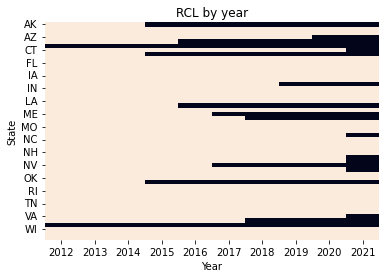

In [28]:
# Draw a heatmap with the numeric values in each cell

rml = cannabis_subset.pivot("stateabbr", "year", "rml")
cmap = sns.cm.rocket_r
ax = sns.heatmap(rml, cmap=cmap, cbar=False)
ax.set(xlabel='Year', ylabel='State')
plt.title('RCL by year')

In [29]:
cannabis_subset.to_csv(fp+"cannabispol_subset_2012_2021.csv", index=False)

In [30]:
regagency = pd.pivot_table(cannabis_subset, values='regagency', index='stateabbr', columns='year', aggfunc='first')

regagency

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Department of Health Services; Department of R...,Department of Health Services; Department of R...
CA,NaN,NaN,NaN,NaN,Bureau of Marijuana Control; Department of Con...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...
CO,Department of Revenue,"Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ..."
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Department of Consumer Protection
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Department of Agriculture; Department of Comme...,Department of Agriculture; Department of Comme...,Department of Agriculture; Department of Comme...
MA,NaN,NaN,NaN,NaN,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission
ME,NaN,NaN,NaN,NaN,NaN,Department of Administrative and Financial Ser...,Department of Administrative and Financial Ser...,Department of Administrative and Financial Ser...,Department of Administrative and Financial Ser...,Department of Administrative and Financial Ser...
MI,NaN,NaN,NaN,NaN,NaN,NaN,Department of Licensing and Regulatory Affairs,"Marijuana Regulatory Agency, Department of Lic...","Marijuana Regulatory Agency, Department of Lic...","Marijuana Regulatory Agency, Department of Lic..."


In [31]:
taxes = pd.pivot_table(cannabis_subset, values='taxes', index='stateabbr', columns='year', aggfunc='first')

taxes

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,$50 per oz. (producer-level),"$50 per oz. any part of bud/flower, $15 per oz...","$50 per oz. any part of bud/flower, $15 per oz...","$50 per oz. any part of bud/flower, $15 per oz...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b..."
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16% cannabis excise tax (retail-level),16% cannabis excise tax (retail-level)
CA,NaN,NaN,NaN,NaN,$9.25 per oz. flowers; $2.75 per oz. leaves (p...,$9.25 per oz. flowers; $2.75 per oz. leaves (p...,$9.25 per oz. flowers; $2.75 per oz. leaves; $...,$9.25 per oz. flowers; $2.75 per oz. leaves; $...,$9.65 per oz. flowers; $2.87 per oz. leaves; $...,$9.65 per oz. flowers; $2.87 per oz. leaves; $...
CO,15% of sales (producer-level),15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$0.00625 per mg of total THC for cannabis plan...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7% of gross receipts (producer-level); 10% for...,7% of gross receipts (producer-level); 10% for...,7% of gross receipts (producer-level); 10% for...
MA,NaN,NaN,NaN,NaN,3.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level)
ME,NaN,NaN,NaN,NaN,NaN,10% of sales (retail-level),Cultivation facility licensees shall pay excis...,Cultivation facility licensees shall pay excis...,Cultivation facility licensees shall pay excis...,Cultivation facility licensees shall pay excis...
MI,NaN,NaN,NaN,NaN,NaN,NaN,10% of sales (retail-level),10% of sales (retail-level),10% of sales (retail-level),10% of sales (retail-level)


In [32]:
cultivationres = pd.pivot_table(cannabis_subset, values='cultivationres', index='stateabbr', columns='year', aggfunc='first')

cultivationres

year,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,
AK,NaN,NaN,NaN,<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note)
CA,NaN,NaN,NaN,"13 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang..."
CO,NaN,"3,600 plants","1,800 plants","1,800 plants","1,800 plants","1,800 plants","1,800 plants","1,800 plants","5 tiers of licenses, nocap on max plant count."
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Micro-cultivators >= 2000 sq ft which can be i...
IL,NaN,NaN,NaN,NaN,NaN,NaN,"Cultivation Centers <=210,000 sqft; Craft Grow...","Cultivation Centers <=210,000 sqft; Craft Grow...","Cultivation Centers <=210,000 sqft; Craft Grow..."
MA,NaN,NaN,NaN,NaN,NaN,"11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t..."
ME,NaN,NaN,NaN,NaN,"2 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi..."
MI,NaN,NaN,NaN,NaN,NaN,"3 license tiers, with cultivation limits rangi...","3 license tiers, with cultivation limits rangi...","3 license tiers, with cultivation limits rangi...","3 license tiers, with cultivation limits rangi..."
NJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"8 license types, with cultivation limits rangi..."


In [33]:
warningreq = pd.pivot_table(cannabis_subset, values='warningreq', index='stateabbr', columns='year', aggfunc='first')

warningreq

year,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,
AK,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Child Access; Impairment of Dri...
CA,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
CO,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Pr...
IL,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Impairment of Dr...,Amount of THC; Breastfeeding; Impairment of Dr...,Amount of THC; Breastfeeding; Impairment of Dr...
MA,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
ME,NaN,NaN,NaN,NaN,Amount of THC; Presence of Cannabis or THC; Se...,Amount of THC; Presence of Cannabis or THC; Se...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
MI,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Child Access; Impairment of Dri...,Amount of THC; Child Access; Impairment of Dri...,Amount of THC; Child Access; Impairment of Dri...


In [34]:
packagingreq = pd.pivot_table(cannabis_subset, values='packagingreq', index='stateabbr', columns='year', aggfunc='first')

packagingreq

year,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,
AK,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Other
CA,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...
CO,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Pr...
IL,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Other,Child-Proof/Resistant; Other,Child-Proof/Resistant; Other
MA,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...
ME,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...
MI,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant,Child-Proof/Resistant; Other,Child-Proof/Resistant; Other,Child-Proof/Resistant; Other


In [35]:
impaireddrivingproh = pd.pivot_table(cannabis_subset, values='impaireddrivingproh', index='stateabbr', columns='year', aggfunc='first')

impaireddrivingproh

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
CA,NaN,NaN,NaN,NaN,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...
CO,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...
DC,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...
MA,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
ME,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...


In [36]:
impaireddrivingproh = pd.pivot_table(cannabis_subset, values='impaireddrivingproh', index='stateabbr', columns='year', aggfunc='first')

impaireddrivingproh

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
CA,NaN,NaN,NaN,NaN,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...
CO,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...
DC,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...
MA,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
ME,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...


In [37]:
productspermitted = pd.pivot_table(cannabis_subset, values='productspermitted', index='stateabbr', columns='year', aggfunc='first')

productspermitted

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
CA,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Concentrates,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
CO,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...
DC,NaN,NaN,NaN,Herbal,Herbal,Herbal,Herbal,Herbal,Herbal,Herbal
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
MA,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
ME,NaN,NaN,NaN,NaN,NaN,Herbal; Tinctures; Concentrates,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...


In [38]:
underageproh = pd.pivot_table(cannabis_subset, values='underageproh', index='stateabbr', columns='year', aggfunc='first')

underageproh


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
CA,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
CO,Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing
DC,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
MA,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
ME,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing


In [39]:
pesticides = pd.pivot_table(cannabis_subset, values='pesticides', index='stateabbr', columns='year', aggfunc='first')

pesticides


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required
CA,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
CO,No Law,Restricted,Restricted,Restricted,Restricted,Restricted,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
MA,NaN,NaN,NaN,NaN,No Law,Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
ME,NaN,NaN,NaN,NaN,NaN,Testing Required,Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
MI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required


In [40]:
advertising_gen = pd.pivot_table(cannabis_subset, values='advertising_gen', index='stateabbr', columns='year', aggfunc='first')

advertising_gen



year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,None,Both,Both,Both,Both,Both,Both
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Content,Content
CA,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both
CO,None,Both,Both,Both,Both,Both,Both,Both,Both,Both
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both
MA,NaN,NaN,NaN,NaN,None,None,Both,Both,Both,Both
ME,NaN,NaN,NaN,NaN,NaN,None,Both,Both,Both,Both
MI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Content,Content,Content


In [41]:
homedelivery = pd.pivot_table(cannabis_subset, values='homedelivery', index='stateabbr', columns='year', aggfunc='first')

homedelivery


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited
CA,NaN,NaN,NaN,NaN,Allowed,Allowed,Allowed,Allowed,Allowed,Allowed
CO,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Allowed with Restrictions,Allowed with Restrictions
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Allowed with Restrictions
DC,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,No Law,No Law,Prohibited,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
ME,NaN,NaN,NaN,NaN,NaN,No Law,Prohibited,Prohibited,Prohibited,Prohibited


In [42]:
advertising_youth = pd.pivot_table(cannabis_subset, values='homedelivery', index='stateabbr', columns='year', aggfunc='first')

advertising_youth


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited
CA,NaN,NaN,NaN,NaN,Allowed,Allowed,Allowed,Allowed,Allowed,Allowed
CO,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Allowed with Restrictions,Allowed with Restrictions
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Allowed with Restrictions
DC,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,No Law,No Law,Prohibited,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
ME,NaN,NaN,NaN,NaN,NaN,No Law,Prohibited,Prohibited,Prohibited,Prohibited


In [43]:
retailsales_offpremises = pd.pivot_table(cannabis_subset, values='retailsales_offpremises', index='stateabbr', columns='year', aggfunc='first')

retailsales_offpremises

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required
CA,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
CO,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required
DC,NaN,NaN,NaN,No,No,No,No,No,No,No
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required
MA,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
ME,NaN,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required


In [44]:
localauthority = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='localauthority', index='stateabbr', columns='year', aggfunc='first')

localauthority


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both,Both
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both
CA,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both
CO,Both,Both,Both,Both,Both,Both,Both,Both,Both,Both
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both
MA,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both
ME,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both
MI,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both


In [45]:
retailsales_onpremises = pd.pivot_table(cannabis_subset, values='retailsales_onpremises', index='stateabbr', columns='year', aggfunc='first')

retailsales_onpremises


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,No,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No
CA,NaN,NaN,NaN,NaN,No,No,No,No,No,No
CO,No,No,No,No,No,No,No,No,Yes – License Required,Yes – License Required
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
DC,NaN,NaN,NaN,No,No,No,No,No,No,No
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No
MA,NaN,NaN,NaN,NaN,No,No,No,Yes – License Required,Yes – License Required,Yes – License Required
ME,NaN,NaN,NaN,NaN,NaN,Yes – License Required,No,No,No,No


In [46]:
publicuse = pd.pivot_table(cannabis_subset, values='publicuse', index='stateabbr', columns='year', aggfunc='first')

publicuse


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Prohibited,Restricted,Restricted,Restricted,Restricted,Restricted,Restricted
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited
CA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
CO,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Restricted,Restricted
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited
DC,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Restricted,Restricted,Restricted
ME,NaN,NaN,NaN,NaN,NaN,Restricted,Prohibited,Prohibited,Prohibited,Prohibited


In [47]:
opencontainer = pd.pivot_table(cannabis_subset, values='opencontainer', index='stateabbr', columns='year', aggfunc='first')

opencontainer


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Law,No Law
CA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
CO,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited
DC,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
ME,NaN,NaN,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law


In [48]:
pricingcontrols = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='pricingcontrols', index='stateabbr', columns='year', aggfunc='first')

pricingcontrols

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
CA,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0
CO,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
DC,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
MA,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
ME,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,1.0,1.0


In [49]:
vertprohibited = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='vertprohibited', index='stateabbr', columns='year', aggfunc='first')

vertprohibited

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
CA,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
CO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
DC,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
MA,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
ME,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [50]:
industrymakeup = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='industrymakeup', index='stateabbr', columns='year', aggfunc='first')

industrymakeup


year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities
CA,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
CO,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities
MA,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
ME,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
MI,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities


In [51]:
trackingreq = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='trackingreq', index='stateabbr', columns='year', aggfunc='first')

trackingreq

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
stateabbr,,,,,,,,,,
AK,NaN,NaN,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
CA,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0
CO,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
DC,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
MA,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0,1.0,1.0
ME,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0


In [52]:
cannabis_subset.to_stata(fp+"cannabispol_2012_2021.dta", version=118)

